# Exploring Neural Population Dynamics in the Visual Cortex During Supervised and Unsupervised Learning 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns

# Load Data

In [143]:
# Use a project-rooted path to the data directory
from pathlib import Path
import os

# Resolve project root (works in notebooks): start from CWD and search upward for a folder containing 'data'
base = '/Users/dimi/Downloads/my stuff/ISP_impact_scholar_2025'#Path.cwd()
#for p in [base, *base.parents]:
#    if (p / 'data').exists():
#        project_root = p
#        break
#else:
project_root = Path(base)

root = str(project_root / 'data')

# print("Looking for data in:", root)
# print("Files in data directory:", os.listdir(root))
sup_bef = 'VR2_2021_03_20_1' #example mouse before supervised learning
sup_aft = 'VR2_2021_04_06_1' #example mouse after supervised learning
unsup_bef = 'TX105_2022_10_08_2' #example mouse before supervised learning
unsup_aft = 'TX105_2022_10_19_2' #example mouse after supervised learning
mouse_type = 'sup_aft' #############change this!!!!
# Load specific files from the directory
spike_file = os.path.join(root, sup_aft + '_SVD_dec.npy')  #### change this !!!!
# print(f"Spike file path: {spike_file}")
beh_path = os.path.join(root, 'Beh_sup_train1_after_learning.npy') #### change this !!!!
# Load data
svd_ = np.load(spike_file, allow_pickle=True).item()
spikes = svd_['U'].T @ svd_['V']  # project from the PC space back to neural space

# Load and process sound cue data
beh = np.load(beh_path, allow_pickle=True).item()[sup_aft]  #### change this !!!!
beh.keys()

/Users/dimi/anaconda3/envs/impact_scholars_env/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator TruncatedSVD from version 1.6.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


dict_keys(['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'UniqWalls', 'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'VRposTime', 'VRpos', 'VRposCum', 'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'Corridor_Length', 'Gray_Space_length', 'Texture_Length', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'RunFr', 'BefCueFr', 'AftCueFr', 'stim_id', 'TrialStim', 'StimTrial', 'StimFrame', 'Reward_Mode', 'Reward_Delay_ms'])

# 1. Extract beh information 
We collect arrays with similar length and put them into a DataFrame (df). At the end we have several df with different lengths 

In [144]:
# Collect only those items that are array-like, not strings, and 1-dimensional
array_keys_1d = [k for k, v in beh.items() 
                 if hasattr(v, '__len__') and not isinstance(v, str) and np.array(beh[k]).ndim == 1]

# Group keys by the length of their arrays
from collections import defaultdict
length_groups = defaultdict(list)
for k in array_keys_1d:
    length_groups[len(beh[k])].append(k)

# Create a DataFrame for each group of arrays with the same length
# Then concatenate them (with different columns) into a single DataFrame, aligning by index
dfs = []
for length, keys in length_groups.items():
    data = {k: np.array(beh[k]) for k in keys}
    df = pd.DataFrame(data)
    dfs.append(df)
    print(f"DataFrame for 1D arrays of length {length}:")
    print(df.head(), "\n")

# Concatenate all DataFrames along columns, aligning by index (outer join)
if dfs:
    beh_df = pd.concat(dfs, axis=1)
    print("Final concatenated DataFrame of all 1D arrays:")
    print(beh_df.head())
else:
    print("No 1D array-like items found in beh.")

DataFrame for 1D arrays of length 470:
   trInd  trInd_odd  trInd_even  ...  SoundDelayFr  SoundDelPos  TrialStim
0      0       True       False  ...     24.212450    18.833322      leaf1
1      1      False        True  ...     79.152434    73.800000      leaf1
2      2       True       False  ...    122.664916   135.231952      leaf1
3      3      False        True  ...    184.000000   197.400000    circle1
4      4       True       False  ...    217.000000   255.200000    circle1

[5 rows x 23 columns] 

DataFrame for 1D arrays of length 2:
  UniqWalls  stim_id
0   circle1        0
1     leaf1        2 

DataFrame for 1D arrays of length 1605:
   LickTrind       LickTime  LickPos Lick_wallName     LickFr
0        0.0  738252.498507      7.6         leaf1  14.462146
1        0.0  738252.498530     15.0         leaf1  20.820456
2        0.0  738252.498551     20.6         leaf1  26.526666
3        0.0  738252.498555     20.6         leaf1  27.869746
4        0.0  738252.498559     20

In [145]:
# Information for each trial in contained here 
dfs[0]

,trInd,trInd_odd,trInd_even,Trial_start_time,Trial_end_time,Gray_space_time,SoundPos,SoundTime,SoundTimeDelay,RewTime,RewPos,isRew,WallType,WallIsProbe,WallName,RewardFr,StartFr,GrayFr,EndFr,SoundFr,SoundDelayFr,SoundDelPos,TrialStim
0,0,True,False,738252.498471,738252.498710,738252.498659,18.800000,738252.498542,738252.498542,738252.498542,18.8,True,1,0,leaf1,24.212450,4.302538,56.339587,70.138628,24.212450,24.212450,18.833322,leaf1
1,1,False,True,738252.498710,738252.498875,738252.498833,13.800000,738252.498742,738252.498742,738252.498742,13.8,True,1,0,leaf1,79.152434,70.231285,104.190428,115.578786,79.152434,79.152434,73.800000,leaf1
2,2,True,False,738252.498875,738252.499087,738252.499053,15.200000,738252.498901,738252.498901,738252.498901,15.2,True,1,0,leaf1,122.664916,115.588379,164.570873,173.877724,122.664916,122.664916,135.231952,leaf1
3,3,False,True,738252.499088,738252.499221,738252.499182,17.400000,738252.499124,738252.499124,NaN,NaN,False,2,0,circle1,NaN,174.018615,199.892919,210.500246,184.000000,184.000000,197.400000,circle1
4,4,True,False,738252.499221,738252.499308,738252.499282,15.200000,738252.499244,738252.499244,NaN,NaN,False,2,0,circle1,NaN,210.516567,227.187651,234.511833,217.000000,217.000000,255.200000,circle1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465,465,False,True,738252.562288,738252.562418,738252.562390,27.000000,738252.562329,738252.562329,738252.562329,27.0,True,1,0,leaf1,17528.847746,17517.447787,17545.616695,17553.111167,17528.847746,17528.847746,27927.046112,leaf1
466,466,True,False,738252.562418,738252.562579,738252.562541,20.000000,738252.562458,738252.562458,738252.562458,20.0,True,1,0,leaf1,17564.180263,17553.167585,17586.849372,17597.281252,17564.180263,17564.180263,27980.028640,leaf1
467,467,False,True,738252.562579,738252.562690,738252.562661,14.800000,738252.562599,738252.562599,738252.562599,14.8,True,1,0,leaf1,17603.007566,17597.290427,17619.976532,17627.965280,17603.007566,17603.007566,28034.826060,leaf1
468,468,True,False,738252.562690,738252.562872,738252.562834,18.400000,738252.562729,738252.562729,738252.562729,18.4,True,1,0,leaf1,17638.625243,17628.023402,17667.318479,17677.791374,17638.625243,17638.625243,28098.400000,leaf1


In [146]:
dfs[2][:20]


,LickTrind,LickTime,LickPos,Lick_wallName,LickFr
0,0.0,738252.498507,7.6,leaf1,14.462146
1,0.0,738252.498530,15.0,leaf1,20.820456
2,0.0,738252.498551,20.6,leaf1,26.526666
3,0.0,738252.498555,20.6,leaf1,27.869746
4,0.0,738252.498559,20.6,leaf1,28.846803
5,0.0,738252.498563,20.6,leaf1,29.856942
6,0.0,738252.498567,20.6,leaf1,30.987009
7,0.0,738252.498569,20.6,leaf1,31.463212
8,0.0,738252.498577,20.6,leaf1,33.689262
9,0.0,738252.498639,32.4,leaf1,50.872038


#### Barplot with number of licks over trials colored by stimulus identity

Does not seem particularly informative but could be useful to compare with same mouse later interaining and for unsupervised mouse

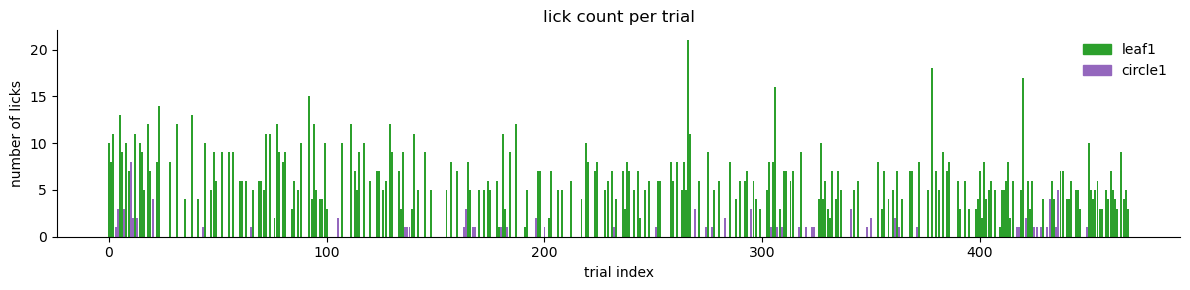

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# df: licking dataframe with columns
# ['LickTrind','LickTime','LickPos','Lick_wallName','LickFr']
df = dfs[2]
# --- per-trial summary (includes no-lick trials as 0) ---
g = df.groupby("LickTrind")

trial = g.agg(
    stim=("Lick_wallName", lambda x: x.iloc[0]),   # assumes constant within a trial
    n_licks=("LickTime", "size"),
).reset_index()

tmin, tmax = int(df["LickTrind"].min()), int(df["LickTrind"].max())
all_trials = pd.DataFrame({"LickTrind": np.arange(tmin, tmax + 1)})

T = all_trials.merge(trial, on="LickTrind", how="left")
T["n_licks"] = T["n_licks"].fillna(0).astype(int)

# NOTE: stim will be NaN for no-lick trials unless you have a separate trial log.
# If you have it (recommended), merge it to fill T["stim"] for all trials.

# --- colors by condition ---
# pick two distinct colors (matplotlib named colors)
color_map = {"leaf1": "tab:green", "circle1": "tab:purple"}
bar_colors = T["stim"].map(color_map).fillna("lightgray")  # gray = unknown stim (often no-lick trials)

# --- bar plot ---
fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(T["LickTrind"].values, T["n_licks"].values, color=bar_colors.values, width=0.9)

ax.set_xlabel("trial index")
ax.set_ylabel("number of licks")
ax.set_title("lick count per trial")

# legend (only show known conditions)
handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[k]) for k in ["leaf1", "circle1"]]
ax.legend(handles, ["leaf1", "circle1"], frameon=False, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
mouse_type
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_number_vs_trials.png')
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_number_vs_trials.pdf',dpi=200)
plt.show()

#### Create dataframe with trial index and lick-no lick response

In [148]:
import numpy as np
import pandas as pd

# df = your licking dataframe with columns:
# ['LickTrind','LickTime','LickPos','Lick_wallName','LickFr']

# 1) summarize lick events within each trial
g = df.groupby("LickTrind")

trial_lick = g.agg(
    stim=("Lick_wallName", lambda x: x.iloc[0]),   # assumes within-trial stimulus is constant
    n_licks=("LickTime", "size"),
    mean_fr=("LickFr", "mean"),
    max_fr=("LickFr", "max"),
).reset_index()

trial_lick["licked"] = 1

# 2) build full trial index range (or use your true number of trials)
tmin, tmax = int(df["LickTrind"].min()), int(df["LickTrind"].max())
all_trials = pd.DataFrame({"LickTrind": np.arange(tmin, tmax + 1)})

# 3) merge and fill missing = no lick trials
lick_df = all_trials.merge(trial_lick, on="LickTrind", how="left")

lick_df["licked"]  = lick_df["licked"].fillna(0).astype(int)
lick_df["n_licks"] = lick_df["n_licks"].fillna(0).astype(int)


# IMPORTANT:
# If stim is missing for no-lick trials, you need a separate trial log to fill it.
# For now, T["stim"] will be NaN on no-lick trials.

In [149]:
### indices of trials where  mouse didnt lick
no_lick_trials = lick_df.loc[lick_df["licked"] == 0, "LickTrind"].to_numpy()

In [150]:
no_lick_trials

array([ 17,  21,  24,  25,  26,  27,  29,  30,  32,  33,  34,  36,  37,
        39,  40,  42,  45,  46,  50,  51,  53,  54,  56,  58,  59,  62,
        64,  67,  68,  73,  75,  79,  82,  83,  86,  89,  90,  91,  96,
       101, 102, 103, 104, 106, 108, 109, 110, 112, 116, 118, 119, 121,
       122, 125, 128, 131, 132, 141, 143, 144, 146, 147, 149, 150, 151,
       152, 153, 154, 156, 158, 159, 161, 162, 169, 171, 173, 176, 177,
       185, 186, 188, 189, 190, 193, 194, 195, 199, 201, 204, 205, 207,
       209, 210, 211, 213, 214, 215, 216, 218, 221, 222, 225, 226, 227,
       230, 234, 235, 240, 242, 245, 247, 249, 250, 254, 255, 256, 257,
       260, 262, 268, 270, 272, 273, 276, 279, 281, 282, 284, 286, 287,
       289, 291, 294, 298, 300, 301, 312, 315, 316, 319, 321, 322, 325,
       333, 337, 338, 339, 340, 343, 345, 346, 347, 349, 351, 352, 354,
       357, 359, 365, 366, 367, 370, 373, 374, 375, 377, 379, 382, 384,
       387, 388, 389, 392, 394, 396, 397, 406, 408, 416, 427, 43

In [151]:
### fill in the stimulus identity for those trials from the behaviour dataframe
# no_lick_trials: array/list of trial indices with no licks (from T)
# dfs[0]: trial-level dataframe with columns ['trInd', 'WallName', ...]
trial_info = dfs[0][["trInd", "WallName"]].drop_duplicates()

# make a lookup dict: trInd -> WallName
stim_lookup = dict(zip(trial_info["trInd"].astype(int), trial_info["WallName"]))

# iterate over no-lick trials and fill in stimulus identity
for tr in no_lick_trials:
    stim = stim_lookup.get(int(tr), None)
    #print(tr, stim)   # stim will be None if that trial index isn't present in dfs[0]
    lick_df.loc[lick_df["LickTrind"] == int(tr), "stim"] = stim

#### Plot learning curves

In [152]:
from scipy.stats import norm

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# assumes lick_df has columns: ['LickTrind','stim','licked','n_licks','mean_fr']
# and you've already filled stim for all trials

# ----------------------------
# metrics (A–D + optional E)
# ----------------------------
is_leaf   = lick_df["stim"].eq("leaf1")
is_circle = lick_df["stim"].eq("circle1")

lick_df = lick_df.sort_values("LickTrind").reset_index(drop=True)

lick_df["correct"] = np.where(is_leaf,   lick_df["licked"].eq(1),
                       np.where(is_circle, lick_df["licked"].eq(0), np.nan)).astype(float)

W = 20
minp = max(3, W//3)

def rolling_rate(mask_trials, mask_event):
    s = mask_event.where(mask_trials)
    return s.rolling(W, min_periods=minp).mean()

# A) rolling accuracy
acc = lick_df["correct"].rolling(W, min_periods=minp).mean()

# B) hit and false alarm rates
hit = rolling_rate(is_leaf, lick_df["licked"])
fa  = rolling_rate(is_circle, lick_df["licked"])

# C) d-prime (window-wise correction)
# use a per-window epsilon based on window trial counts per condition (more proper than 1/(2W))
n_leaf_win   = is_leaf.rolling(W, min_periods=minp).sum()
n_circle_win = is_circle.rolling(W, min_periods=minp).sum()

eps_hit = (1 / (2 * n_leaf_win)).replace([np.inf, -np.inf], np.nan)
eps_fa  = (1 / (2 * n_circle_win)).replace([np.inf, -np.inf], np.nan)

hit_c = hit.clip(lower=eps_hit, upper=1 - eps_hit)
fa_c  = fa.clip(lower=eps_fa,  upper=1 - eps_fa)

dprime = norm.ppf(hit_c) - norm.ppf(fa_c)

# E) bias / criterion 
# c = -0.5 * (z(H) + z(FA))
criterion = -0.5 * (norm.ppf(hit_c) + norm.ppf(fa_c))

# D) vigor / engagement
nlick_leaf   = lick_df["n_licks"].where(is_leaf).rolling(W, min_periods=minp).mean()
nlick_circle = lick_df["n_licks"].where(is_circle).rolling(W, min_periods=minp).mean()


lick_prob = lick_df["licked"].rolling(W, min_periods=minp).mean()

x = lick_df["LickTrind"].to_numpy()



#### Accuracy and d'

**Accuracy** mixes **discrimination** with **response bias**. A mouse can get satisfying accuracy by being very conservative (almost never licking) if circle trials are common. This would result low hit rate and low false alarm rate, and typically a modest/low d′.

Thus we consider also d' that focuses on **separability of the two response distributions** implied by H and F.

**hit rate** $H = P(\text{lick} \mid \text{leaf1})$

**false alarm rate** $F = P(\text{lick} \mid \text{circle1})$

$d' = \Phi^{-1}(H) - \Phi^{-1}(F)$,
where $\Phi^{-1}$ is the inverse CDF of a standard normal.

Roughly

- $d' \approx 0$: chance-level discrimination
- $d' \approx 1$: decent separation
- $d' \approx 2$: strong separation


d' is the distance between the two internal evidence distributions, measured in units of their noise.
d' is comparatively **less sensitive to bias** and **more about discriminability**.

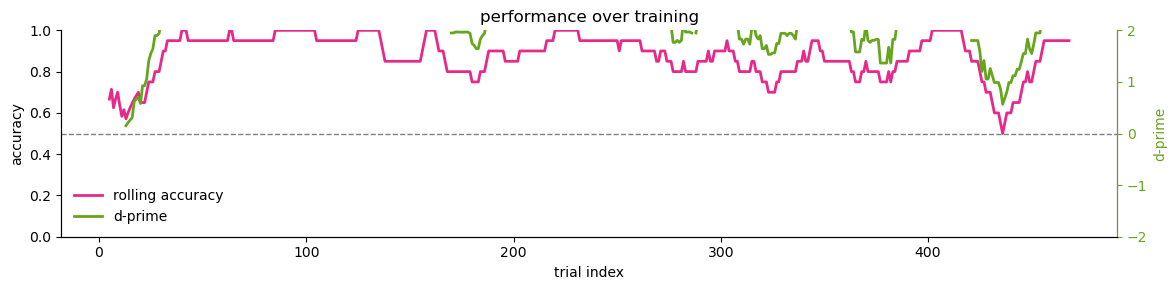

In [154]:

# 1) accuracy + d'
import matplotlib.pyplot as plt

# dark2 palette (matplotlib default qualitative set)
pal = plt.get_cmap("Dark2")

fig, ax = plt.subplots(figsize=(12, 3))

# left axis: accuracy
acc_line, = ax.plot(x, acc.to_numpy(), label="rolling accuracy", color=pal(3), lw=2)
ax.set_xlabel("trial index")
ax.set_ylabel("accuracy")
ax.set_title("performance over training")
ax.spines["top"].set_visible(False)
ax.set_ylim(0,1)

# right axis: d'
ax2 = ax.twinx()
d_line, = ax2.plot(x, np.asarray(dprime), label="d-prime", color=pal(4), lw=2)
ax2.set_ylabel("d-prime", color=d_line.get_color())
ax2.tick_params(axis="y", colors=d_line.get_color())
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color(d_line.get_color())
ax2.set_ylim(-2,2)
ax2.axhline(0, linestyle="--", c='grey',linewidth=1)

# combined legend
lines = [acc_line, d_line]
labels = [l.get_label() for l in lines]
ax.legend(lines, labels, frameon=False, loc=3)

plt.tight_layout()
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_accuracy_dprime_vs_trials.png')
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_accuracy_dprime_vs_trials.pdf',dpi=200)
plt.show()

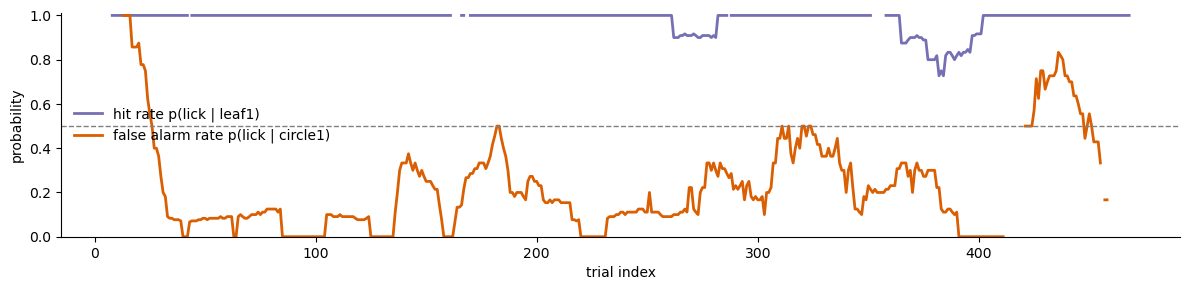

In [155]:
# 2) hit rate + false alarm rate
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(x, hit.to_numpy(), label="hit rate p(lick | leaf1)", color=pal(2), lw=2)
ax.plot(x, fa.to_numpy(), label="false alarm rate p(lick | circle1)", color=pal(1), lw=2)
ax.set_ylim(0,1.01)
ax.axhline(0.5, linestyle="--", c='grey',linewidth=1)
ax.set_xlabel("trial index")
ax.set_ylabel("probability")
#ax.set_title("signal detection rates")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_signal_detection_rates_vs_trials.png')
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_signal_detection_rates_vs_trials.pdf',dpi=200)
plt.show()



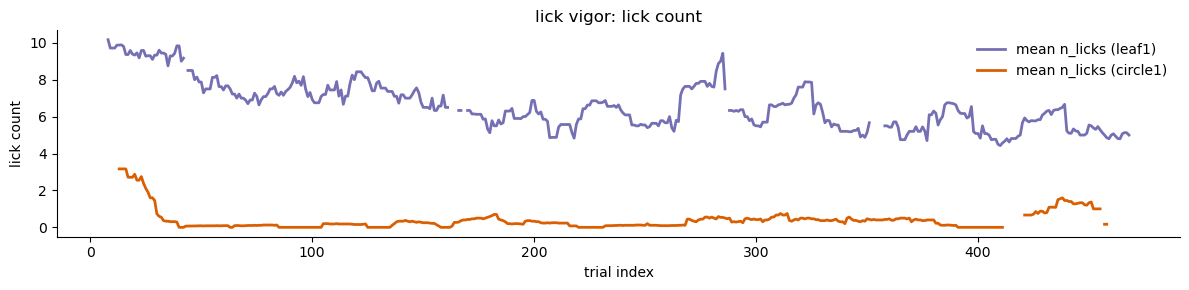

In [156]:
# 3) vigor: lick counts   by stimulus
import matplotlib.pyplot as plt

# 3) vigor: lick counts and lick frequency by stimulus
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(x, nlick_leaf.to_numpy(), label="mean n_licks (leaf1)", color=pal(2), lw=2)
ax.plot(x, nlick_circle.to_numpy(), label="mean n_licks (circle1)", color=pal(1), lw=2)
ax.set_xlabel("trial index")
ax.set_ylabel("lick count")
ax.set_title("lick vigor: lick count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()

plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_lick_vigor_vs_trials.png')
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_lick_vigor_vs_trials.pdf',dpi=200)
plt.show()

#### How often the mouse licks overall (engagement/motivation) and how biased its decision rule is (a tendency to lick vs withhold that’s not explained by the stimulus)

##### Engagement

This is just the rolling mean of P(lick) across trials:
$P(\text{lick}) \approx \frac{\#\text{lick trials}}{\#\text{trials}}$

- **Higher values:**  the mouse is licking on a larger fraction of trials (more “go” responses).
- **Drops:** indicate reduced engagement/satiety/fatigue, or learning to withhold on circle trials (so you have to compare it with hit/FA plots).

**Notice!** This curve mixes both stimuli. If circle trials are common and the mouse learns to stop licking on circle, P(lick) can go down even if it’s doing great.

##### Bias (criterion)

This comes from signal detection theory. You computed it from the corrected hit/FA:
$c = -\tfrac{1}{2}\big(z(H)+z(F)\big),
\quad z(\cdot)=\Phi^{-1}(\cdot)$

- **More negative c:** liberal criterion → easier to lick (tends to say “go” more often), so both hit rate and false alarm rate tend to be high.
- **More positive c:** conservative criterion → harder to lick (tends to withhold), so both hit rate and false alarm rate tend to be low.
- **Near 0:** roughly “unbiased” in the symmetric equal-variance Gaussian SDT sense.



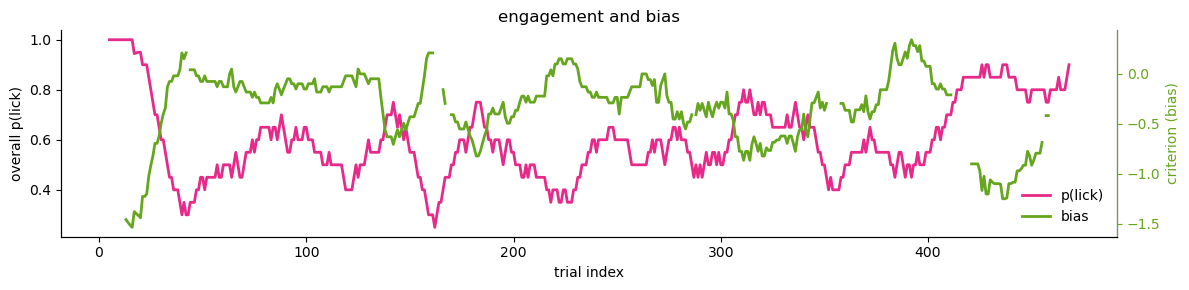

In [162]:
# 4) overall lick probability + criterion (bias)
fig, ax = plt.subplots(figsize=(12, 3))

# left axis: overall p(lick)
l1, = ax.plot(x, lick_prob.to_numpy(), label="p(lick)", color=pal(3), lw=2)
ax.set_xlabel("trial index")
ax.set_ylabel("overall p(lick)")
ax.tick_params(axis="y")
ax.set_title("engagement and bias")
ax.spines["top"].set_visible(False)
#ax.spines["left"].set_color(l1.get_color())

# right axis: criterion
ax2 = ax.twinx()
l2, = ax2.plot(x, np.asarray(criterion), label="bias", color=pal(4), lw=2)
ax2.set_ylabel("criterion (bias)", color=l2.get_color())
ax2.tick_params(axis="y", colors=l2.get_color())
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_color(l2.get_color())

# combined legend
lines = [l1, l2]
labels = [ln.get_label() for ln in lines]
ax.legend(lines, labels, frameon=False, loc=4)

plt.tight_layout()
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_EngagementNBias_vs_trials.png')
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_EngagementNBias_vs_trials.pdf',dpi=200)
plt.show()

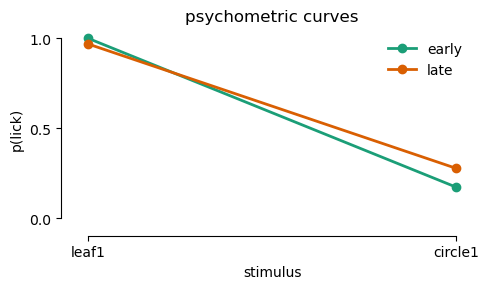

In [163]:


# sort by trial index
lick_df = lick_df.sort_values("LickTrind").reset_index(drop=True)

# split early/late (by trial order)
mid = len(lick_df) // 2
early = lick_df.iloc[:mid].copy()
late  = lick_df.iloc[mid:].copy()

# psychometric points: P(lick | stim) for each stim
stim_order = ["leaf1", "circle1"]

def p_lick_by_stim(d):
    return d.groupby("stim")["licked"].mean().reindex(stim_order)

p_early = p_lick_by_stim(early)
p_late  = p_lick_by_stim(late)

# plot (two-point "psychometric" curve)
pal = plt.get_cmap("Dark2")
xpos = np.arange(len(stim_order))

fig, ax = plt.subplots(figsize=(5, 3))

ax.plot(xpos, p_early.to_numpy(), marker="o", lw=2, label="early", color=pal(0))
ax.plot(xpos, p_late.to_numpy(),  marker="o", lw=2, label="late",  color=pal(1))

ax.set_xticks(xpos)
ax.set_xticklabels(stim_order)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("stimulus")
ax.set_ylabel("p(lick)")
ax.set_title("psychometric curves")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)


# add a small gap so spines don't meet
gap = 6
ax.spines["left"].set_position(("outward", gap))
ax.spines["bottom"].set_position(("outward", gap))

# only 3 y ticks
ax.locator_params(axis="y", nbins=3)
xt = ax.get_xticks()


ax.spines["bottom"].set_bounds(xt[0], xt[-1])
ax.spines["left"].set_bounds(0, 1)


plt.tight_layout()
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_Psychometric_curves_Early_Late_Trials.png')
plt.savefig(base + '/plots/' + mouse_type + '_1_LickStatistics_Psychometric_curves_Early_Late_Trials.pdf',dpi=200)
plt.show()